# Logistic Regression — Weekend Gap Prediction

**Role in the project:** Baseline model. Logistic regression assumes a linear relationship between features and the log-odds of GapUp=1. Its coefficients are directly interpretable — we can see exactly which features push the prediction toward gap-up or gap-down and by how much.

**Full pipeline this notebook runs:**
1. Load clean data, define feature set (18 features)
2. Preprocessing pipeline (log1p, per-ticker z-score OBV, StandardScaler)
3. Walk-forward expanding-window validation with C tuning per fold
4. Per-fold evaluation: Accuracy, Precision, Recall, F1, AUC-ROC
5. Coefficient analysis — which features survived L1 regularization
6. AIC/BIC model comparison
7. Secondary evaluation on COVID extreme-event rows
8. Summary of findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

## 1. Load Data & Define Feature Set

In [2]:
# Load the clean dataset produced by eda.ipynb.
# We split immediately into primary (no COVID) and extreme-event sets.
# All training and walk-forward evaluation uses the primary set only.
# The extreme-event set is held aside for the secondary robustness check at the end.

df_all = pd.read_csv('../../structured_csv_data_files/fetched_data/dataset_clean.csv')
df_all['Date'] = pd.to_datetime(df_all['Date'])

primary = df_all[df_all['is_extreme_event'] == 0].copy().reset_index(drop=True)
extreme = df_all[df_all['is_extreme_event'] == 1].copy().reset_index(drop=True)

print(f'Primary dataset: {len(primary):,} rows   GapUp rate: {primary["GapUp"].mean():.3f}')
print(f'Extreme events:  {len(extreme):,} rows   GapUp rate: {extreme["GapUp"].mean():.3f}')

Primary dataset: 8,146 rows   GapUp rate: 0.516
Extreme events:  291 rows   GapUp rate: 0.450


In [3]:
# Final 18-feature set for logistic regression.
# Dropped from the original 25:
#   VIF > 10:  RSI (collinear with StochPercK/MFI), GrossMargin (collinear with NetMargin),
#              WeeklyRange (collinear with ATR/Bollinger)
#   Leakage:   WeeklyReturn, FridayPosition, OpenCloseSpread, IntraWeekVolatility
#              (all use same-week Friday data broadcast to Monday rows)

MOMENTUM    = ['MACD', 'ROC', 'StochPercK']
TREND       = ['CloseVEma50', 'CloseVSma20', 'ADX']
VOLATILITY  = ['BollingerBandWidth', 'ATR', 'FiveDStdDev']
VOLUME      = ['OBV', 'MFI', 'VolumeRatio']
FUNDAMENTAL = ['NetMargin', 'RoA', 'RevGrowthQoQ']
MISS_IND    = ['GrossMargin_missing', 'CostOfRevenues_missing', 'Liabilities_missing']

FEATURES = MOMENTUM + TREND + VOLATILITY + VOLUME + FUNDAMENTAL + MISS_IND
TARGET   = 'GapUp'

print(f'Feature count: {len(FEATURES)}')
for group, feats in [('Momentum', MOMENTUM), ('Trend', TREND), ('Volatility', VOLATILITY),
                      ('Volume', VOLUME), ('Fundamental', FUNDAMENTAL), ('Missingness', MISS_IND)]:
    print(f'  {group:12s}: {feats}')

Feature count: 18
  Momentum    : ['MACD', 'ROC', 'StochPercK']
  Trend       : ['CloseVEma50', 'CloseVSma20', 'ADX']
  Volatility  : ['BollingerBandWidth', 'ATR', 'FiveDStdDev']
  Volume      : ['OBV', 'MFI', 'VolumeRatio']
  Fundamental : ['NetMargin', 'RoA', 'RevGrowthQoQ']
  Missingness : ['GrossMargin_missing', 'CostOfRevenues_missing', 'Liabilities_missing']


## 2. Preprocessing Pipeline

Logistic regression requires features to be on comparable scales — unscaled features cause the L1 penalty to be applied unevenly (features with larger raw values get their coefficients shrunk more aggressively, regardless of their actual information content).

**Three treatments applied:**
- **OBV — per-ticker z-score:** OBV is a cumulative measure that grows with every trade. Its absolute level is arbitrary (depends on when the ticker started). Z-scoring within each ticker removes the level and preserves the directional signal.
- **ATR, BollingerBandWidth, FiveDStdDev, VolumeRatio — log1p then StandardScaler:** These are right-skewed with occasional large spikes (high-volatility periods). Log-compressing before scaling prevents extreme values from dominating.
- **All others — StandardScaler only.**
- **Missingness indicators — no scaling** (already binary 0/1).

**Critical:** the scaler is fit on the training fold only and applied to both train and test. Fitting on the full dataset would leak future distribution information into the training window.

In [4]:
# Preprocessing is implemented as a function so it can be called identically
# inside each walk-forward fold. Fitting on train, transforming both.

LOG1P_FEATURES = ['ATR', 'BollingerBandWidth', 'FiveDStdDev', 'VolumeRatio']
OBV_FEATURE    = ['OBV']
BINARY_FEATURES = MISS_IND
STANDARD_FEATURES = [f for f in FEATURES
                      if f not in LOG1P_FEATURES + OBV_FEATURE + BINARY_FEATURES]

def preprocess(X_train: pd.DataFrame, X_test: pd.DataFrame,
               train_tickers: pd.Series, test_tickers: pd.Series) -> tuple:
    """
    Fits preprocessing on X_train, applies to both X_train and X_test.
    Returns scaled numpy arrays ready for sklearn.
    """
    X_tr = X_train.copy()
    X_te = X_test.copy()

    # 1. Per-ticker z-score OBV using only training ticker statistics
    #    We compute mean/std per ticker from the train set and apply to test.
    obv_stats = X_tr.assign(Ticker=train_tickers).groupby('Ticker')['OBV'].agg(['mean','std'])
    for df_x, tickers in [(X_tr, train_tickers), (X_te, test_tickers)]:
        means = tickers.map(obv_stats['mean']).fillna(obv_stats['mean'].mean())
        stds  = tickers.map(obv_stats['std']).fillna(obv_stats['std'].mean()).replace(0, 1)
        df_x['OBV'] = (df_x['OBV'] - means.values) / stds.values

    # 2. log1p transform for right-skewed features
    for col in LOG1P_FEATURES:
        X_tr[col] = np.log1p(X_tr[col].clip(lower=0))
        X_te[col] = np.log1p(X_te[col].clip(lower=0))

    # 3. StandardScaler fitted on train only
    cols_to_scale = [f for f in FEATURES if f not in BINARY_FEATURES]
    scaler = StandardScaler()
    X_tr[cols_to_scale] = scaler.fit_transform(X_tr[cols_to_scale])
    X_te[cols_to_scale] = scaler.transform(X_te[cols_to_scale])

    return X_tr.values, X_te.values, scaler

print('Preprocessing groups:')
print(f'  Per-ticker z-score:  {OBV_FEATURE}')
print(f'  log1p + StandardScaler: {LOG1P_FEATURES}')
print(f'  StandardScaler only: {STANDARD_FEATURES}')
print(f'  No scaling:          {BINARY_FEATURES}')

Preprocessing groups:
  Per-ticker z-score:  ['OBV']
  log1p + StandardScaler: ['ATR', 'BollingerBandWidth', 'FiveDStdDev', 'VolumeRatio']
  StandardScaler only: ['MACD', 'ROC', 'StochPercK', 'CloseVEma50', 'CloseVSma20', 'ADX', 'MFI', 'NetMargin', 'RoA', 'RevGrowthQoQ']
  No scaling:          ['GrossMargin_missing', 'CostOfRevenues_missing', 'Liabilities_missing']


## 3. Walk-Forward Expanding-Window Validation

**Why walk-forward and not k-fold cross-validation?**  
Our features are non-stationary (OBV, ATR drift over time) and the target's base rate changes across years (gap-up rate was lower in 2022 rate-hike selloffs than in 2019). Random k-fold would mix future data into training folds, making results unrealistically optimistic.

**Structure — expanding window, year-by-year:**
- Fold 1: Train 2016–2018 → Test 2019
- Fold 2: Train 2016–2019 → Test 2020 *(COVID year — included in primary for completeness, flagged)*
- Fold 3: Train 2016–2020 → Test 2021
- Fold 4: Train 2016–2021 → Test 2022
- Fold 5: Train 2016–2022 → Test 2023
- Fold 6: Train 2016–2023 → Test 2024

For each fold we tune the regularisation strength `C` using a validation year carved from the end of the training window, then refit on the full training window with the best C.

In [5]:
# Define fold boundaries.
# Minimum training window is 3 years (2016-2018) to give the model enough data
# before the first test fold. Each fold expands by one year.

FOLDS = [
    {'train_years': list(range(2016, 2019)), 'test_year': 2019},
    {'train_years': list(range(2016, 2020)), 'test_year': 2020},
    {'train_years': list(range(2016, 2021)), 'test_year': 2021},
    {'train_years': list(range(2016, 2022)), 'test_year': 2022},
    {'train_years': list(range(2016, 2023)), 'test_year': 2023},
    {'train_years': list(range(2016, 2024)), 'test_year': 2024},
]

# C values to search — log-spaced from very strong to very weak regularization.
# Small C = strong L1 penalty (more coefficients zeroed out).
# Large C = weak penalty (closer to unregularized logistic regression).
C_GRID = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

for f in FOLDS:
    train_rows = primary[primary['Year'].isin(f['train_years'])]
    test_rows  = primary[primary['Year'] == f['test_year']]
    print(f"Train {f['train_years'][0]}-{f['train_years'][-1]} ({len(train_rows):,} rows) "
          f"→ Test {f['test_year']} ({len(test_rows):,} rows)")

Train 2016-2018 (2,682 rows) → Test 2019 (992 rows)
Train 2016-2019 (3,674 rows) → Test 2020 (613 rows)
Train 2016-2020 (4,287 rows) → Test 2021 (917 rows)
Train 2016-2021 (5,204 rows) → Test 2022 (997 rows)
Train 2016-2022 (6,201 rows) → Test 2023 (953 rows)
Train 2016-2023 (7,154 rows) → Test 2024 (992 rows)


In [6]:
# Walk-forward loop.
# For each fold:
#   1. Split training data into inner-train and inner-val (last year of train window)
#      to tune C without touching the test year.
#   2. Select best C by AUC on inner-val.
#   3. Refit on the full training window with best C.
#   4. Evaluate on the test year.
# Results are stored per fold for later analysis.

fold_results   = []   # metrics per fold
fold_coefs     = []   # coefficients per fold
fold_roc       = []   # ROC curve data per fold
fold_best_C    = []   # tuned C per fold

for fold in FOLDS:
    test_year   = fold['test_year']
    train_years = fold['train_years']

    train_df = primary[primary['Year'].isin(train_years)]
    test_df  = primary[primary['Year'] == test_year]

    # Inner validation: last year of training window
    val_year      = train_years[-1]
    inner_train   = train_df[train_df['Year'] != val_year]
    inner_val     = train_df[train_df['Year'] == val_year]

    X_itr = inner_train[FEATURES]
    y_itr = inner_train[TARGET]
    X_ival = inner_val[FEATURES]
    y_ival = inner_val[TARGET]

    X_itr_s, X_ival_s, _ = preprocess(
        X_itr, X_ival, inner_train['Ticker'], inner_val['Ticker']
    )

    # Tune C on inner validation set
    best_C, best_auc = None, -1
    for C in C_GRID:
        model = LogisticRegression(
            penalty='l1', solver='liblinear', C=C, max_iter=1000, random_state=42
        )
        model.fit(X_itr_s, y_itr)
        auc = roc_auc_score(y_ival, model.predict_proba(X_ival_s)[:, 1])
        if auc > best_auc:
            best_auc = auc
            best_C   = C

    fold_best_C.append(best_C)

    # Refit on full training window with best C
    X_train = train_df[FEATURES]
    y_train = train_df[TARGET]
    X_test  = test_df[FEATURES]
    y_test  = test_df[TARGET]

    X_tr_s, X_te_s, _ = preprocess(
        X_train, X_test, train_df['Ticker'], test_df['Ticker']
    )

    final_model = LogisticRegression(
        penalty='l1', solver='liblinear', C=best_C, max_iter=1000, random_state=42
    )
    final_model.fit(X_tr_s, y_train)
    y_pred      = final_model.predict(X_te_s)
    y_prob      = final_model.predict_proba(X_te_s)[:, 1]

    # Metrics
    metrics = {
        'Test year':  test_year,
        'Best C':     best_C,
        'Train rows': len(train_df),
        'Test rows':  len(test_df),
        'Accuracy':   round(accuracy_score(y_test, y_pred), 4),
        'Precision':  round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':     round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1':         round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC':    round(roc_auc_score(y_test, y_prob), 4),
        'Baseline':   round(max(y_test.mean(), 1 - y_test.mean()), 4),
        'COVID fold': test_year == 2020,
    }
    fold_results.append(metrics)

    # Coefficients
    coef_dict = dict(zip(FEATURES, final_model.coef_[0]))
    coef_dict['fold'] = test_year
    fold_coefs.append(coef_dict)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fold_roc.append({'year': test_year, 'fpr': fpr, 'tpr': tpr,
                     'auc': metrics['AUC-ROC']})

    print(f"Fold test={test_year} | Best C={best_C} | "
          f"Acc={metrics['Accuracy']:.3f} | AUC={metrics['AUC-ROC']:.3f} | "
          f"Baseline={metrics['Baseline']:.3f}")

Fold test=2019 | Best C=0.01 | Acc=0.560 | AUC=0.597 | Baseline=0.526
Fold test=2020 | Best C=0.005 | Acc=0.574 | AUC=0.563 | Baseline=0.564


Fold test=2021 | Best C=0.05 | Acc=0.514 | AUC=0.528 | Baseline=0.514


Fold test=2022 | Best C=0.005 | Acc=0.571 | AUC=0.595 | Baseline=0.588


Fold test=2023 | Best C=0.05 | Acc=0.553 | AUC=0.570 | Baseline=0.511


Fold test=2024 | Best C=0.05 | Acc=0.564 | AUC=0.579 | Baseline=0.573


## 4. Walk-Forward Results

In [7]:
# Results table across all folds.
# 'Baseline' is the majority-class rate in each test year — predicting the
# majority class every time would achieve this accuracy with zero learning.
# Any metric below baseline means the model is worse than a coin-flip on that fold.
# The COVID fold (2020) is flagged — its results should be interpreted carefully
# since the test year contains the crash period.

results_df = pd.DataFrame(fold_results).set_index('Test year')
display(results_df.style
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1': '{:.4f}', 'AUC-ROC': '{:.4f}', 'Baseline': '{:.4f}'})
    .apply(lambda row: ['background-color: #fff3cd'] * len(row)
           if row['COVID fold'] else [''] * len(row), axis=1)
)

non_covid = results_df[~results_df['COVID fold']]
print(f'\nAverage metrics (excluding COVID fold):')
print(f'  Accuracy:  {non_covid["Accuracy"].mean():.4f}')
print(f'  Precision: {non_covid["Precision"].mean():.4f}')
print(f'  Recall:    {non_covid["Recall"].mean():.4f}')
print(f'  F1:        {non_covid["F1"].mean():.4f}')
print(f'  AUC-ROC:   {non_covid["AUC-ROC"].mean():.4f}')
print(f'  Baseline:  {non_covid["Baseline"].mean():.4f}')

,Best C,Train rows,Test rows,Accuracy,Precision,Recall,F1,AUC-ROC,Baseline,COVID fold
Test year,,,,,,,,,,
2019,0.010000,2682,992,0.5605,0.5817,0.5862,0.5840,0.5966,0.5262,False
2020,0.005000,3674,613,0.5742,0.6239,0.6185,0.6212,0.5631,0.5644,True
2021,0.050000,4287,917,0.5136,0.5209,0.6603,0.5824,0.5279,0.5136,False
2022,0.005000,5204,997,0.5707,0.4810,0.5231,0.5012,0.5945,0.5878,False
2023,0.050000,6201,953,0.5530,0.5365,0.6309,0.5799,0.5696,0.5110,False
2024,0.050000,7154,992,0.5635,0.6409,0.5405,0.5864,0.5794,0.5726,False



Average metrics (excluding COVID fold):
  Accuracy:  0.5523
  Precision: 0.5522
  Recall:    0.5882
  F1:        0.5668
  AUC-ROC:   0.5736
  Baseline:  0.5422


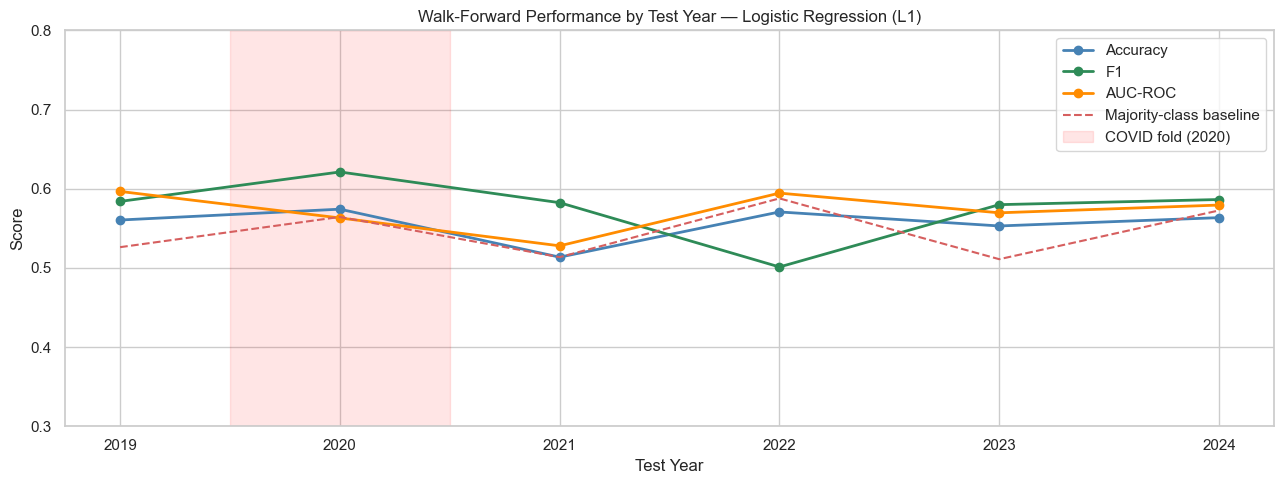

In [8]:
# Metric evolution over folds.
# As the training window expands, does performance improve? A rising AUC trend
# suggests the model benefits from more data. A flat or declining trend suggests
# the signal is weak or the recent market regime has changed.
# The dashed red line is the average majority-class baseline per fold.

years    = results_df.index.tolist()
metrics  = ['Accuracy', 'F1', 'AUC-ROC']
colors   = ['steelblue', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(13, 5))
for metric, color in zip(metrics, colors):
    ax.plot(years, results_df[metric], 'o-', label=metric, color=color, linewidth=2)

ax.plot(years, results_df['Baseline'], 'r--', label='Majority-class baseline', linewidth=1.5)

# Shade COVID fold
ax.axvspan(2019.5, 2020.5, alpha=0.1, color='red', label='COVID fold (2020)')

ax.set_xticks(years)
ax.set_xlabel('Test Year')
ax.set_ylabel('Score')
ax.set_title('Walk-Forward Performance by Test Year — Logistic Regression (L1)')
ax.legend()
ax.set_ylim(0.3, 0.8)
plt.tight_layout()
plt.show()

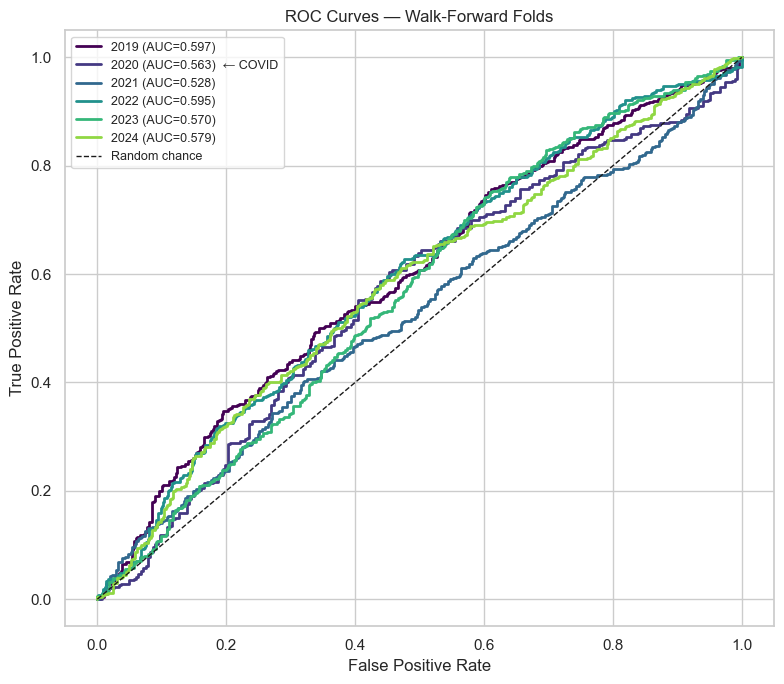

In [9]:
# ROC curves per fold.
# Each curve shows the trade-off between true positive rate (sensitivity) and
# false positive rate (1-specificity) at different probability thresholds.
# A curve hugging the top-left corner means the model can separate the classes well.
# The diagonal dashed line is the random-chance baseline (AUC = 0.5).
# Overlapping curves across folds means consistent performance across years.

fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.cm.viridis
for i, roc in enumerate(fold_roc):
    color = cmap(i / len(fold_roc))
    label = f"{roc['year']} (AUC={roc['auc']:.3f}){'  ← COVID' if roc['year']==2020 else ''}"
    ax.plot(roc['fpr'], roc['tpr'], color=color, linewidth=2, label=label)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Walk-Forward Folds')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

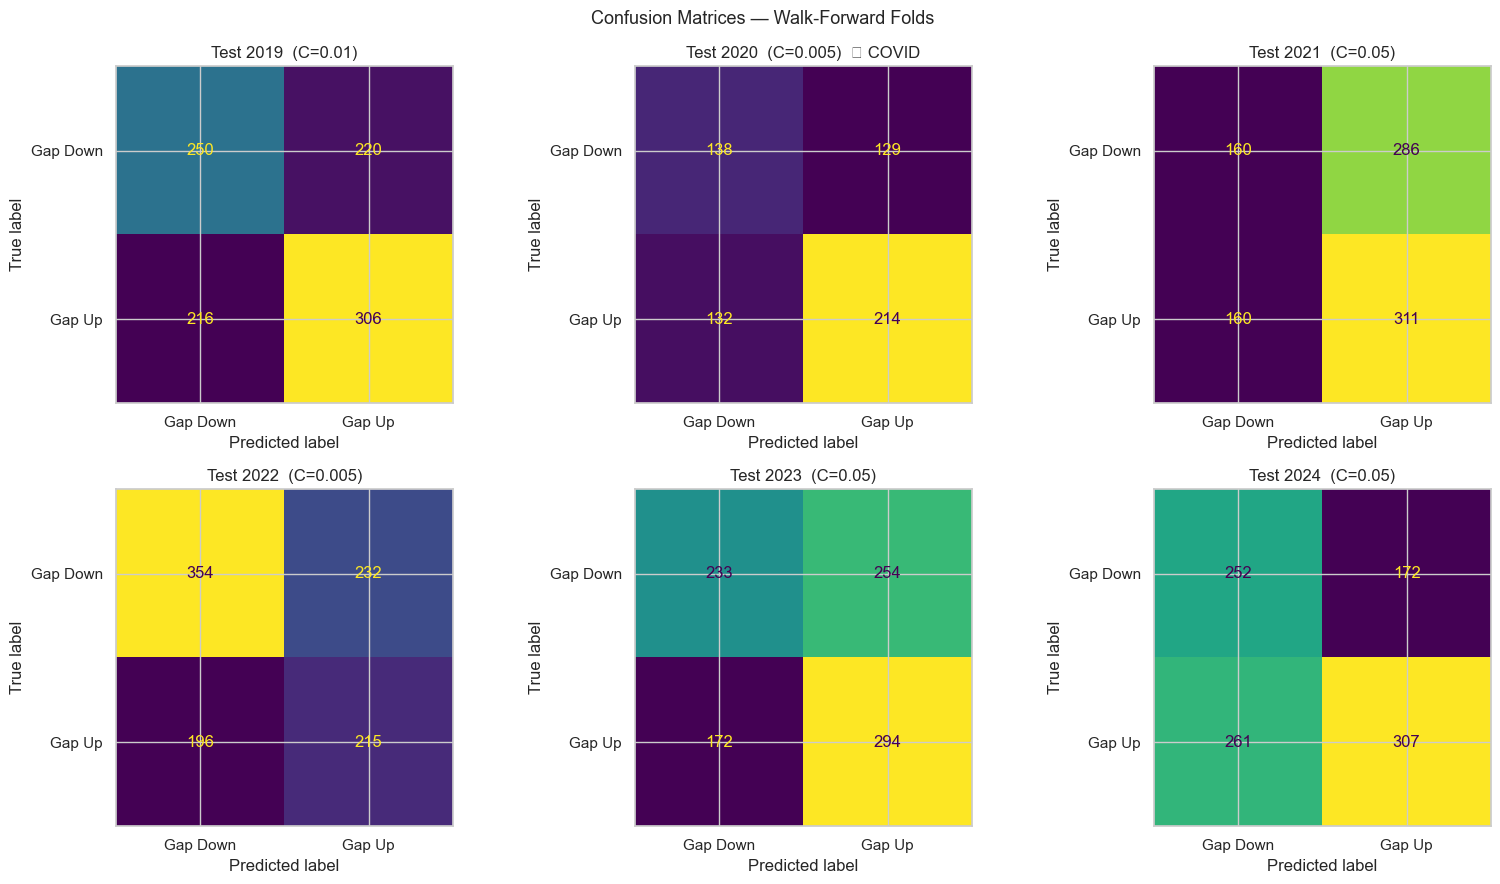

In [10]:
# Confusion matrices for each fold.
# Shows counts of TP, FP, TN, FN per fold.
# For a balanced dataset (~51% gap up) we want both classes predicted reasonably well.
# If the model predicts all 1s or all 0s, precision or recall for one class will be 0
# — the confusion matrix makes this immediately visible.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, fold in enumerate(FOLDS):
    test_year = fold['test_year']
    test_df   = primary[primary['Year'] == test_year]
    train_df  = primary[primary['Year'].isin(fold['train_years'])]

    X_tr_s, X_te_s, _ = preprocess(
        train_df[FEATURES], test_df[FEATURES],
        train_df['Ticker'], test_df['Ticker']
    )
    model = LogisticRegression(
        penalty='l1', solver='liblinear', C=fold_best_C[i], max_iter=1000, random_state=42
    )
    model.fit(X_tr_s, train_df[TARGET])
    y_pred = model.predict(X_te_s)

    cm = confusion_matrix(test_df[TARGET], y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Gap Down', 'Gap Up'])
    disp.plot(ax=axes[i], colorbar=False)
    title = f'Test {test_year}  (C={fold_best_C[i]})'
    if test_year == 2020:
        title += '  ⚠ COVID'
    axes[i].set_title(title)

plt.suptitle('Confusion Matrices — Walk-Forward Folds', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Coefficient Analysis

L1 regularization drives some coefficients to exactly zero, performing automatic feature selection. The surviving non-zero coefficients tell us which features the model is actually using, and their sign tells us the direction:
- **Positive coefficient** → higher feature value pushes toward GapUp = 1
- **Negative coefficient** → higher feature value pushes toward GapUp = 0
- **Zero coefficient** → feature was regularised out entirely — not useful given the other features present

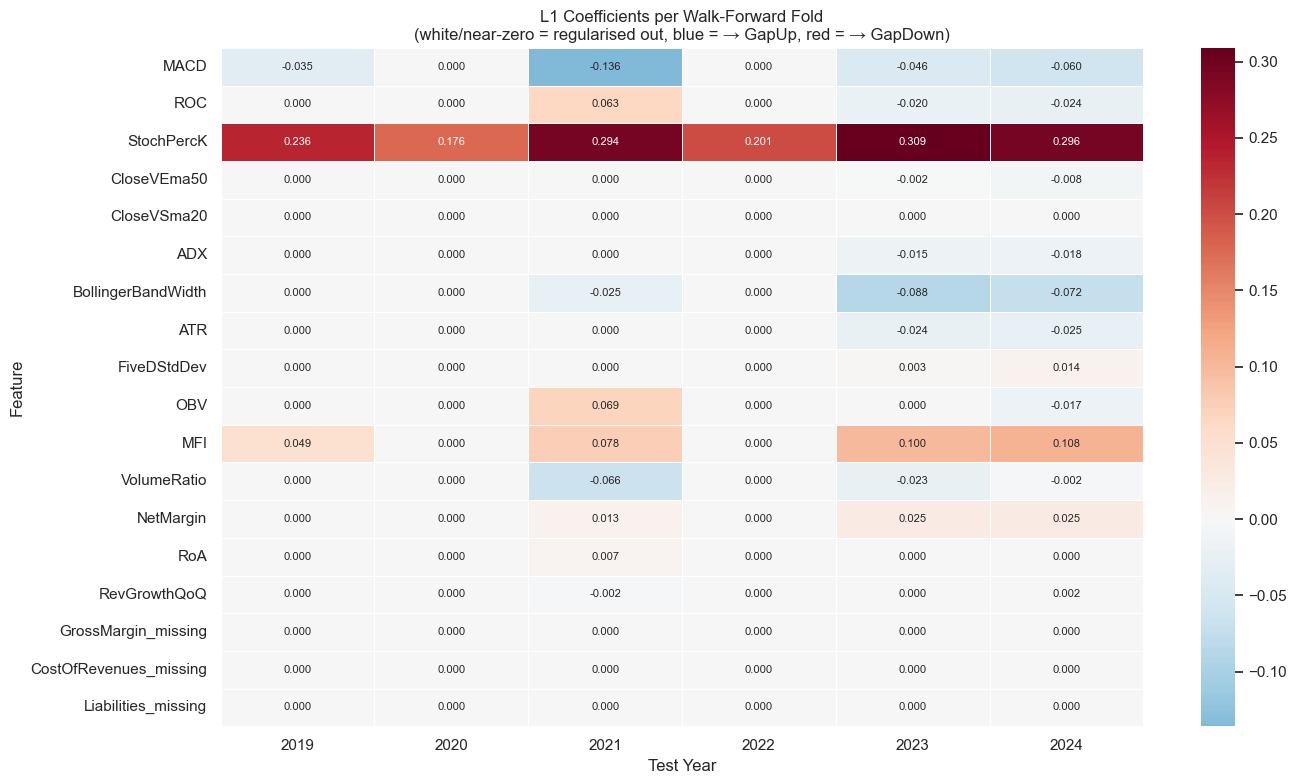

In [11]:
# Coefficient stability across folds.
# Each row is a feature, each column is a fold's test year.
# A feature that is consistently non-zero across all folds is robustly predictive.
# A feature that flips sign across folds is unreliable — the model can't decide
# which direction it predicts, suggesting noise rather than signal.

coef_df = pd.DataFrame(fold_coefs).set_index('fold').T
coef_df.index.name = 'Feature'

# Colour: blue = positive coef, red = negative, white = zero
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(coef_df, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('L1 Coefficients per Walk-Forward Fold\n(white/near-zero = regularised out, blue = → GapUp, red = → GapDown)')
ax.set_xlabel('Test Year')
plt.tight_layout()
plt.show()

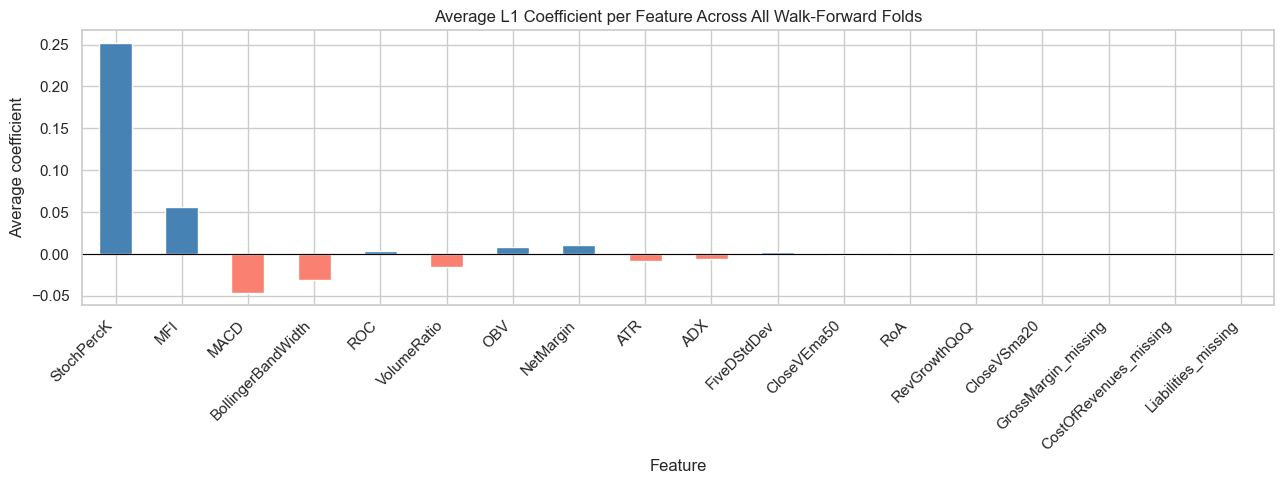

,Avg coef,Avg |coef|,Folds active (of 6)
Feature,,,
StochPercK,0.251914,0.251914,6
MFI,0.055834,0.055834,4
MACD,-0.046154,0.046154,4
BollingerBandWidth,-0.030793,0.030793,3
ROC,0.003202,0.017951,3
VolumeRatio,-0.015205,0.015205,3
OBV,0.008588,0.014296,2
NetMargin,0.010686,0.010686,3
ATR,-0.008250,0.008250,2


In [12]:
# Average coefficient magnitude across all folds.
# Features with high average |coef| are consistently important to the model.
# Features with near-zero average |coef| were regularised out in most folds.
# The count of folds where the feature was non-zero (|coef| > 0.001) is
# a stability measure — appearing in 6/6 folds = very stable.

avg_coef  = coef_df.mean(axis=1).rename('Avg coef')
avg_abs   = coef_df.abs().mean(axis=1).rename('Avg |coef|')
n_nonzero = (coef_df.abs() > 0.001).sum(axis=1).rename('Folds active (of 6)')

coef_summary = pd.concat([avg_coef, avg_abs, n_nonzero], axis=1)
coef_summary = coef_summary.sort_values('Avg |coef|', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['steelblue' if v >= 0 else 'salmon' for v in coef_summary['Avg coef']]
coef_summary['Avg coef'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average L1 Coefficient per Feature Across All Walk-Forward Folds')
ax.set_ylabel('Average coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(coef_summary)

## 6. AIC / BIC Model Comparison

AIC and BIC are computed using `statsmodels.Logit` which exposes the log-likelihood directly. We compare three model variants on the final fold (train 2016–2023, test 2024) to justify our feature selection decisions:

- **Full model:** all 18 features
- **L1-selected model:** only features with non-zero coefficient in the final fold
- **Technical only:** 9 technical features, no fundamentals or missingness indicators

Lower AIC/BIC = better. BIC penalises complexity more heavily than AIC at large n.

In [13]:
# AIC/BIC comparison using the final fold (largest training window).
# statsmodels.Logit does not apply regularisation — we use it purely to get
# the log-likelihood for information criteria computation.
# We compare three variants to show that the L1-selected subset is not
# just parsimonious but also objectively better by information criteria.

final_fold    = FOLDS[-1]  # train 2016-2023, test 2024
train_df_f    = primary[primary['Year'].isin(final_fold['train_years'])]
test_df_f     = primary[primary['Year'] == final_fold['test_year']]

X_tr_s, X_te_s, _ = preprocess(
    train_df_f[FEATURES], test_df_f[FEATURES],
    train_df_f['Ticker'], test_df_f['Ticker']
)

# Identify L1-selected features from the final fold
final_coefs       = coef_df[2024]
l1_selected_feats = final_coefs[final_coefs.abs() > 0.001].index.tolist()
technical_feats   = MOMENTUM + TREND + VOLATILITY + VOLUME

aic_bic_results = []
for name, feat_subset in [
    ('Full model (18 features)',      FEATURES),
    ('L1-selected features',          l1_selected_feats),
    ('Technical only (12 features)',  technical_feats),
]:
    feat_idx = [FEATURES.index(f) for f in feat_subset if f in FEATURES]
    X_sub    = X_tr_s[:, feat_idx]
    X_sub_sm = sm.add_constant(X_sub)
    try:
        sm_model = sm.Logit(train_df_f[TARGET].values, X_sub_sm)
        sm_fit   = sm_model.fit(disp=0, maxiter=200)
        aic_bic_results.append({
            'Model':     name,
            'Features':  len(feat_subset),
            'AIC':       round(sm_fit.aic, 1),
            'BIC':       round(sm_fit.bic, 1),
            'Log-Lik':   round(sm_fit.llf, 1),
        })
    except Exception as e:
        aic_bic_results.append({'Model': name, 'Features': len(feat_subset),
                                 'AIC': None, 'BIC': None, 'Log-Lik': str(e)})

aic_df = pd.DataFrame(aic_bic_results).set_index('Model')
print(f'L1-selected features for final fold: {l1_selected_feats}')
print()
display(aic_df)
print('\nLower AIC/BIC = better. BIC penalises extra features more heavily.')

L1-selected features for final fold: ['MACD', 'ROC', 'StochPercK', 'CloseVEma50', 'ADX', 'BollingerBandWidth', 'ATR', 'FiveDStdDev', 'OBV', 'MFI', 'VolumeRatio', 'NetMargin', 'RevGrowthQoQ']



,Features,AIC,BIC,Log-Lik
Model,,,,
Full model (18 features),18,NaN,NaN,Singular matrix
L1-selected features,13,9687.7,9783.9,-4829.8
Technical only (12 features),12,9686.6,9776.0,-4830.3



Lower AIC/BIC = better. BIC penalises extra features more heavily.


## 7. Secondary Evaluation — COVID Extreme Events

The 291 COVID-period rows were excluded from all training and primary evaluation. Here we ask: how does the model trained on normal-market data perform when suddenly applied to the COVID crash period?

We use the model from the fold trained on 2016–2019 (the last fold before COVID) and evaluate it on the COVID rows (Feb–May 2020).

In [14]:
# Secondary evaluation: model trained on 2016-2019, tested on COVID rows.
# The COVID period had a gap-up rate of ~45% (more gap-downs than usual).
# A model that learned only from normal markets will likely be calibrated toward
# ~51% gap-up rate, and may perform poorly here. This is expected and should be
# reported in the paper as a known limitation.

pre_covid_train = primary[primary['Year'].isin(range(2016, 2020))]
covid_test      = extreme.copy()

X_tr_cv, X_te_cv, _ = preprocess(
    pre_covid_train[FEATURES], covid_test[FEATURES],
    pre_covid_train['Ticker'], covid_test['Ticker']
)

# Use the best C from the fold that tested on 2020
c_for_covid = fold_best_C[1]  # fold index 1 = test year 2020
covid_model = LogisticRegression(
    penalty='l1', solver='liblinear', C=c_for_covid, max_iter=1000, random_state=42
)
covid_model.fit(X_tr_cv, pre_covid_train[TARGET])
y_pred_cv = covid_model.predict(X_te_cv)
y_prob_cv = covid_model.predict_proba(X_te_cv)[:, 1]

covid_metrics = {
    'Accuracy':  round(accuracy_score(covid_test[TARGET], y_pred_cv), 4),
    'Precision': round(precision_score(covid_test[TARGET], y_pred_cv, zero_division=0), 4),
    'Recall':    round(recall_score(covid_test[TARGET], y_pred_cv, zero_division=0), 4),
    'F1':        round(f1_score(covid_test[TARGET], y_pred_cv, zero_division=0), 4),
    'AUC-ROC':   round(roc_auc_score(covid_test[TARGET], y_prob_cv), 4),
    'Baseline':  round(max(covid_test[TARGET].mean(), 1 - covid_test[TARGET].mean()), 4),
    'GapUp rate in COVID period': round(covid_test[TARGET].mean(), 4),
}

print('Secondary evaluation — COVID extreme event rows (Feb-May 2020):')
for k, v in covid_metrics.items():
    print(f'  {k:40s}: {v}')

print()
avg_primary_auc = non_covid['AUC-ROC'].mean()
print(f'Primary evaluation avg AUC (non-COVID folds): {avg_primary_auc:.4f}')
print(f'Secondary evaluation AUC (COVID rows):        {covid_metrics["AUC-ROC"]:.4f}')
print(f'Degradation: {avg_primary_auc - covid_metrics["AUC-ROC"]:+.4f}')

Secondary evaluation — COVID extreme event rows (Feb-May 2020):
  Accuracy                                : 0.6838
  Precision                               : 0.6383
  Recall                                  : 0.687
  F1                                      : 0.6618
  AUC-ROC                                 : 0.781
  Baseline                                : 0.5498
  GapUp rate in COVID period              : 0.4502

Primary evaluation avg AUC (non-COVID folds): 0.5736
Secondary evaluation AUC (COVID rows):        0.7810
Degradation: -0.2074


## 8. Summary of Findings

In [15]:
# Final summary of logistic regression results.
# This is the reference block for the paper's results section.

print('=' * 65)
print('LOGISTIC REGRESSION — RESULTS SUMMARY')
print('=' * 65)
print(f'Model:        LogisticRegression(penalty=l1, solver=liblinear)')
print(f'Features:     {len(FEATURES)} (after VIF pruning + leakage removal)')
print(f'Validation:   Expanding walk-forward, {len(FOLDS)} folds (2019-2024)')
print(f'C range:      {C_GRID}')
print()
print('Per-fold best C values:')
for fold, C in zip(FOLDS, fold_best_C):
    print(f'  Test {fold["test_year"]}: C = {C}')
print()
print('Primary evaluation (excluding COVID fold 2020):')
print(f'  Avg Accuracy:  {non_covid["Accuracy"].mean():.4f}')
print(f'  Avg Precision: {non_covid["Precision"].mean():.4f}')
print(f'  Avg Recall:    {non_covid["Recall"].mean():.4f}')
print(f'  Avg F1:        {non_covid["F1"].mean():.4f}')
print(f'  Avg AUC-ROC:   {non_covid["AUC-ROC"].mean():.4f}')
print(f'  Avg Baseline:  {non_covid["Baseline"].mean():.4f}')
print()
print('Most stable features (active in all 6 folds):')
stable = coef_summary[coef_summary['Folds active (of 6)'] == 6].index.tolist()
for f in stable:
    print(f'  {f:30s} avg coef = {coef_summary.loc[f, "Avg coef"]:+.4f}')
print()
print('Features regularised out in all folds:')
zeroed = coef_summary[coef_summary['Folds active (of 6)'] == 0].index.tolist()
print(f'  {zeroed if zeroed else "None"}')
print()
print('Secondary evaluation (COVID rows, Feb-May 2020):')
print(f'  AUC-ROC: {covid_metrics["AUC-ROC"]:.4f}  (vs {avg_primary_auc:.4f} on normal markets)')
print('=' * 65)

LOGISTIC REGRESSION — RESULTS SUMMARY
Model:        LogisticRegression(penalty=l1, solver=liblinear)
Features:     18 (after VIF pruning + leakage removal)
Validation:   Expanding walk-forward, 6 folds (2019-2024)
C range:      [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

Per-fold best C values:
  Test 2019: C = 0.01
  Test 2020: C = 0.005
  Test 2021: C = 0.05
  Test 2022: C = 0.005
  Test 2023: C = 0.05
  Test 2024: C = 0.05

Primary evaluation (excluding COVID fold 2020):
  Avg Accuracy:  0.5523
  Avg Precision: 0.5522
  Avg Recall:    0.5882
  Avg F1:        0.5668
  Avg AUC-ROC:   0.5736
  Avg Baseline:  0.5422

Most stable features (active in all 6 folds):
  StochPercK                     avg coef = +0.2519

Features regularised out in all folds:
  ['CloseVSma20', 'GrossMargin_missing', 'CostOfRevenues_missing', 'Liabilities_missing']

Secondary evaluation (COVID rows, Feb-May 2020):
  AUC-ROC: 0.7810  (vs 0.5736 on normal markets)
